# Task 4 — Valutazione dei classificatori manuali su `training.csv`

**Corso:** Fondamenti e Applicazioni del Machine Learning (FML 2026)

La traccia chiede di prendere i classificatori del Task 2 (**1R** e **Naïve Bayes**),
valutarli su `training.csv` (o un suo sottoinsieme) e **ottimizzarne** le prestazioni.

Rispetto al Task 2 (12 istanze, leave-one-out) qui lavoriamo su **41.176 istanze**,
quindi:
- usiamo un **holdout stratificato** (Lezione 8): 70% training, 30% test, mantenendo
  la proporzione delle classi;
- usiamo metriche adatte a una **classe sbilanciata** (~11% di `yes`): non solo
  accuratezza, ma **precision, recall, F1** e **matrice di confusione**.

Mostreremo anche l'**effetto di `duration`** (con e senza), per quantificare il
*data leakage* discusso nel Task 3.

> **Stile di codice.** Vettoriale, senza cicli `for` espliciti; stile dei notebook
> del corso.

## 0. Setup e dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8")

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

In [2]:
df = pd.read_csv("../data/processed/training.csv")
nominali = ["job", "marital", "education", "default", "housing", "loan",
            "contact", "month", "day_of_week", "poutcome"]
numeriche = ["age", "duration", "campaign", "pdays", "previous", "emp.var.rate",
             "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
print(f"Dataset: {df.shape[0]} istanze")
print(f"Classe: {df['y'].value_counts().to_dict()}")

Dataset: 41176 istanze
Classe: {0: 36537, 1: 4639}


### 0.1 Il baseline da battere
Con classi sbilanciate, un classificatore "stupido" che predice **sempre `no`**
ottiene già un'accuratezza altissima. È il **riferimento minimo**: un modello utile
deve fare meglio di così, soprattutto sul **recall** della classe `yes`.

In [3]:
baseline_acc = (df["y"] == 0).mean()
print(f"Baseline 'sempre no': accuratezza = {baseline_acc:.2%}, ma recall su 'yes' = 0%")

Baseline 'sempre no': accuratezza = 88.73%, ma recall su 'yes' = 0%


### 0.2 Separazione train/test (holdout stratificato)
`stratify=y` garantisce che train e test abbiano la stessa proporzione di `yes`
(Lezione 8). `random_state` rende la divisione riproducibile.

In [4]:
df_tr, df_te = train_test_split(df, test_size=0.3, stratify=df["y"], random_state=10)
print(f"Train: {len(df_tr)} | Test: {len(df_te)}")
print(f"Proporzione 'yes' - train: {df_tr['y'].mean():.3f}, test: {df_te['y'].mean():.3f}")

Train: 28823 | Test: 12353
Proporzione 'yes' - train: 0.113, test: 0.113


---
## 1. Naïve Bayes su `training.csv`

Usiamo `GaussianNB` di sklearn (controprova del Task 2). Gli attributi nominali
vengono codificati in interi con `OrdinalEncoder`. Definiamo una funzione che
addestra e valuta, con o senza `duration`.

In [5]:
def valuta_nb(usa_duration):
    nums = numeriche if usa_duration else list(pd.Index(numeriche).drop("duration"))
    cols = nums + nominali
    # codifica nominali (fit sul training, transform su entrambi: niente leakage)
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    Xtr = df_tr[cols].copy(); Xte = df_te[cols].copy()
    Xtr[nominali] = enc.fit_transform(Xtr[nominali])
    Xte[nominali] = enc.transform(Xte[nominali])
    clf = GaussianNB().fit(Xtr, df_tr["y"])
    pred = clf.predict(Xte)
    return pd.Series({
        "accuracy":  accuracy_score(df_te["y"], pred),
        "precision": precision_score(df_te["y"], pred),
        "recall":    recall_score(df_te["y"], pred),
        "f1":        f1_score(df_te["y"], pred),
    }), confusion_matrix(df_te["y"], pred)

In [6]:
nb_con, cm_con = valuta_nb(True)
nb_senza, cm_senza = valuta_nb(False)

confronto_nb = pd.DataFrame({"con duration": nb_con, "senza duration": nb_senza})
confronto_nb.round(4)

,con duration,senza duration
accuracy,0.8442,0.8315
precision,0.3801,0.3401
recall,0.6056,0.5266
f1,0.4670,0.4133


### 1.1 Matrici di confusione a confronto

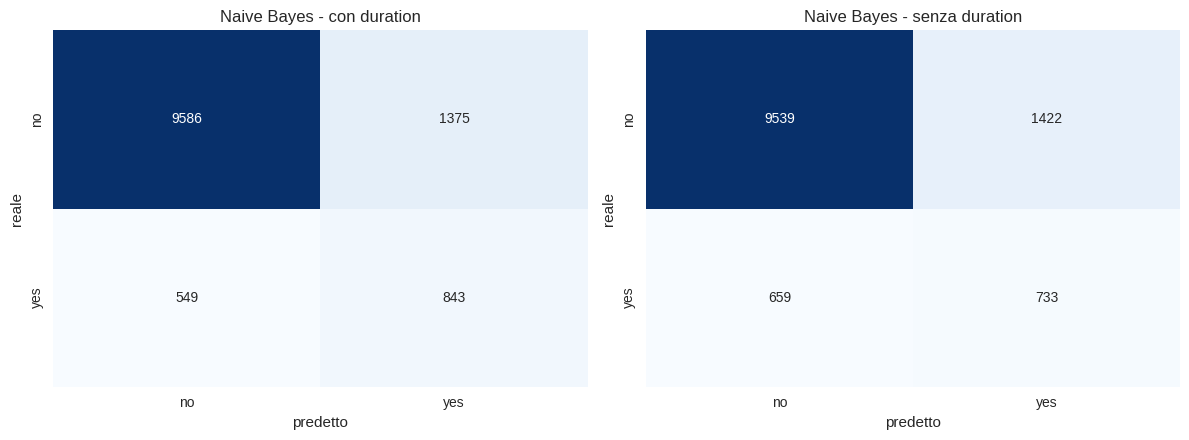

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

def plot_cm(cm, titolo, ax):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["no", "yes"], yticklabels=["no", "yes"])
    ax.set_title(titolo); ax.set_xlabel("predetto"); ax.set_ylabel("reale")

plot_cm(cm_con, "Naive Bayes - con duration", axes[0])
plot_cm(cm_senza, "Naive Bayes - senza duration", axes[1])
plt.tight_layout()
plt.show()

**Osservazioni:**
- **Accuratezza sotto il baseline** (~84% vs ~89%): Naïve Bayes "sacrifica" un po' di
  accuratezza globale, ma in cambio **individua molti `yes`** (recall ~50-60%) che il
  baseline ignorerebbe completamente. Per una campagna di marketing è proprio ciò che
  serve: trovare i clienti propensi.
- **Effetto di `duration`:** includerlo alza F1 e recall — è il **data leakage**
  quantificato. Quel guadagno è illusorio: nella realtà `duration` non sarebbe
  disponibile prima della chiamata. Per questo nel Task 5 lo escluderemo.

---
## 2. 1R su `training.csv`

Riusiamo l'idea del Task 2 (errori via `crosstab`), adattata al dataset grande. Per
gli attributi numerici discretizziamo con `pd.qcut` (intervalli a uguale frequenza).
**Ottimizzazione:** proviamo diversi numeri di intervalli (`bins`).

In [8]:
def errori_1R(attr_series, y):
    tab = pd.crosstab(attr_series, y)
    return int((tab.sum(axis=1) - tab.max(axis=1)).sum())

### 2.1 Quale attributo sceglie 1R?
Calcoliamo gli errori di ogni attributo sul training (numerici discretizzati in 5
intervalli). Ricordiamo: un attributo che predice "sempre no" fa tanti errori quanti
sono i `yes`.

In [9]:
def err_attr(a):
    if a in numeriche:
        return errori_1R(pd.qcut(df_tr[a], q=5, duplicates="drop"), df_tr["y"])
    return errori_1R(df_tr[a], df_tr["y"])

attr_tutti = pd.concat([pd.Series(nominali), pd.Series(numeriche)])
errori_tutti = attr_tutti.apply(err_attr); errori_tutti.index = attr_tutti.values
n_yes = int((df_tr["y"] == 1).sum())
print(f"Errori del baseline (sempre 'no') = numero di 'yes' = {n_yes}\n")
errori_tutti.sort_values().head(8)

Errori del baseline (sempre 'no') = numero di 'yes' = 3247



poutcome     2951
month        3229
education    3247
job          3247
default      3247
housing      3247
loan         3247
marital      3247
dtype: int64

Si vede che **quasi tutti** gli attributi fanno esattamente `n_yes` errori: la
loro regola 1R degenera nel **predire sempre `no`**. Solo **`poutcome`** e **`month`**
fanno meglio del baseline. È un limite strutturale di 1R su dati sbilanciati: con un
solo attributo è difficile catturare la classe rara.

### 2.2 Implementazione e valutazione di 1R (con ottimizzazione dei bin)

In [10]:
def addestra_predici_1R(n_bins, usa_duration):
    nums = numeriche if usa_duration else list(pd.Index(numeriche).drop("duration"))
    # errori per attributo
    def err(a):
        if a in nums:
            return errori_1R(pd.qcut(df_tr[a], q=n_bins, duplicates="drop"), df_tr["y"])
        return errori_1R(df_tr[a], df_tr["y"])
    attrs = pd.concat([pd.Series(nominali), pd.Series(nums)])
    errori = attrs.apply(err); errori.index = attrs.values
    best = errori.idxmin()
    # regola + predizione sul test
    if best in nums:
        binned_tr, bins = pd.qcut(df_tr[best], q=n_bins, duplicates="drop", retbins=True)
        regola = df_tr["y"].groupby(binned_tr).agg(lambda s: s.mode()[0])
        binned_te = pd.cut(df_te[best], bins=bins, include_lowest=True)
        pred = binned_te.map(regola).fillna(0).astype(int)
    else:
        regola = df_tr["y"].groupby(df_tr[best]).agg(lambda s: s.mode()[0])
        pred = df_te[best].map(regola).fillna(0).astype(int)
    return pd.Series({
        "attributo": best,
        "accuracy":  accuracy_score(df_te["y"], pred),
        "recall":    recall_score(df_te["y"], pred),
        "f1":        f1_score(df_te["y"], pred),
    })

In [11]:
# proviamo 3, 5, 10 bin (con duration), niente for: apply su una Series
prove = pd.Series([3, 5, 10])
risultati_bin = prove.apply(lambda nb: addestra_predici_1R(nb, True))
risultati_bin.index = ["bins=3", "bins=5", "bins=10"]
risultati_bin

,attributo,accuracy,recall,f1
bins=3,poutcome,0.896948,0.191092,0.294737
bins=5,poutcome,0.896948,0.191092,0.294737
bins=10,poutcome,0.896948,0.191092,0.294737


Il numero di bin **non cambia** il risultato, perché 1R sceglie comunque
`poutcome` (nominale). Confrontiamo ora 1R con e senza `duration`.

In [12]:
r_con = addestra_predici_1R(5, True)
r_senza = addestra_predici_1R(5, False)
pd.DataFrame({"con duration": r_con, "senza duration": r_senza})

,con duration,senza duration
attributo,poutcome,poutcome
accuracy,0.896948,0.896948
recall,0.191092,0.191092
f1,0.294737,0.294737


---
## 3. Confronto finale 1R vs Naïve Bayes

Mettiamo a confronto i due classificatori (senza `duration`, scenario realistico) e
il baseline.

In [13]:
confronto = pd.DataFrame({
    "Baseline (sempre no)": {"accuracy": baseline_acc, "recall": 0.0, "f1": 0.0},
    "1R (senza duration)":  addestra_predici_1R(5, False)[["accuracy","recall","f1"]],
    "Naive Bayes (senza duration)": nb_senza[["accuracy","recall","f1"]],
}).T
confronto.round(4)

,accuracy,recall,f1
Baseline (sempre no),0.887337,0.0,0.0
1R (senza duration),0.896948,0.191092,0.294737
Naive Bayes (senza duration),0.831539,0.52658,0.413307


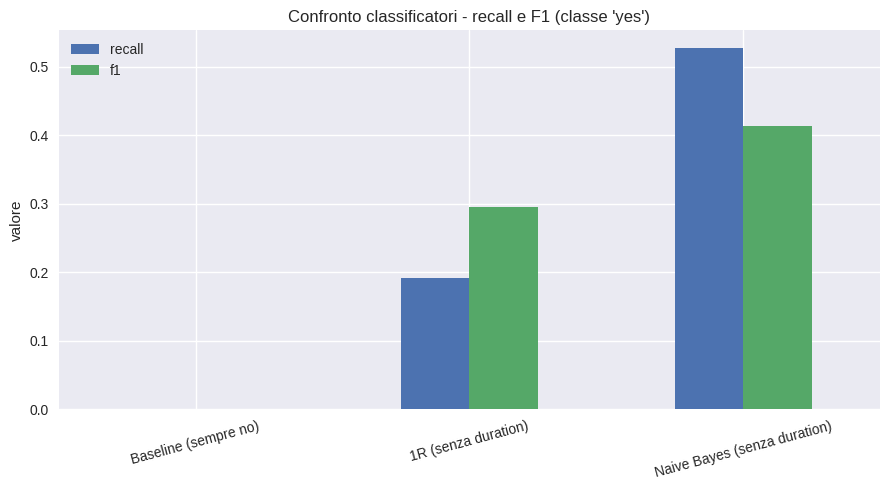

In [14]:
# Visualizziamo F1 e recall (le metriche che contano su classe sbilanciata)
confronto[["recall", "f1"]].plot(kind="bar", figsize=(9, 5), rot=15)
plt.title("Confronto classificatori - recall e F1 (classe 'yes')")
plt.ylabel("valore"); plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

---
## 4. Analisi critica e conclusioni

**Sul confronto 1R vs Naïve Bayes:**
- **1R** ottiene un'**accuratezza alta** (sceglie `poutcome` e batte di poco il
  baseline), ma un **recall molto basso**: cattura pochi `yes`. È trasparente e
  semplice, ma su dati sbilanciati il suo singolo attributo non basta.
- **Naïve Bayes** ha accuratezza più bassa ma **recall nettamente migliore**: usando
  tutti gli attributi individua molti più clienti propensi. Per l'obiettivo di
  business (marketing) è preferibile.

**Sull'ottimizzazione:**
- Per 1R abbiamo provato diversi numeri di **bin** per i numerici: ininfluente, perché
  vince comunque un attributo nominale (`poutcome`).
- L'accuratezza **non** è la metrica giusta qui: il baseline all'89% lo dimostra.
  **F1 e recall** sulla classe `yes` sono molto più informativi.

**Sull'effetto `duration`:**
- Includerlo migliora le metriche di entrambi i modelli, ma è un guadagno **illusorio**
  (*data leakage*): non sarà disponibile in un contesto reale. Conferma la decisione di
  **escluderlo** nel Task 5.

**Prossimo passo (Task 5):** addestrare più classificatori con Scikit-Learn, con
preprocessing completo (one-hot, scaling), ottimizzazione degli iperparametri e
selezione del modello migliore sul test set.